# Contrastive retrieval comparison

Compare the released MLP contrastive pipeline with the mixed-baseline CNN on identical complete PubMed (3,066), Nilearn (79), and NeuroVault (202) test splits. This notebook uses the paired atlas-free protocol; set `INCLUDE_FINETUNED = True` only for an explicit domain-fine-tuning ablation.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from neurovlm import AtlasFreeCNNDataProvider
from neurovlm.evaluation import (
    default_comparison_matrix,
    evaluate_contrastive_comparison,
)

DOMAINS = ("pubmed", "nilearn", "neurovault")
LIMIT_PER_DOMAIN = None  # full test split; set an integer only for a quick run
INCLUDE_FINETUNED = False  # explicit opt-in
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVALUATION_SCOPE = (
    "full test split"
    if LIMIT_PER_DOMAIN is None
    else f"first {LIMIT_PER_DOMAIN} test pairs per domain"
)


## Run the comparison

The provider retrieves the root-level split JSONLs, shared volume tensor, and normalized SPECTER2 text cache from Hugging Face. CNN rows consume that published cache. MLP rows re-encode the same raw positive texts with the released MLP SPECTER2 `adhoc_query` preprocessing. Resources use the normal Hugging Face cache and are reused across domains.

In [2]:
results = []
for domain in DOMAINS:
    selections = default_comparison_matrix(
        "contrastive",
        domains=(domain,),
        include_finetuned=INCLUDE_FINETUNED,
    )
    provider = AtlasFreeCNNDataProvider(
        domain=domain,
        limit=LIMIT_PER_DOMAIN,
    )
    results.append(evaluate_contrastive_comparison(
        selections=selections,
        provider=provider,
        device=DEVICE,
    ))

summary = pd.DataFrame(row for result in results for row in result.summary)
recall_curves = pd.DataFrame(
    row for result in results for row in result.recall_curves
)
by_sample = pd.DataFrame(row for result in results for row in result.by_sample)
manifest = pd.DataFrame(row for result in results for row in result.manifest)

summary.sort_values(["evaluation_domain", "family", "variant"])


There are adapters available but none are activated for the forward pass.
There are adapters available but none are activated for the forward pass.
There are adapters available but none are activated for the forward pass.


,model_id,family,task,domain,variant,evaluation_domain,status,comparison_protocol,comparison_space,text_preprocessing,...,mean_random_recall@10,mean_recall@50,mean_random_recall@50,mean_auc,mean_paper_recall_curve_auc,mean_normalized_k_recall_curve_auc,loss,normalized_k_recall_curve_auc,paper_recall_curve_auc,full_recall_curve_auc_k1_to_N
5,cnn_contrastive_mixed_baseline_neurovault_eval...,cnn,contrastive,neurovault,mixed_baseline,neurovault,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.049505,0.839109,0.247525,0.886004,0.886004,0.886004,3.407764,0.886004,0.886004,0.886004
4,mlp_contrastive_eval_neurovault,mlp,contrastive,None,text,neurovault,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.049505,0.356436,0.247525,0.585776,0.585776,0.585776,6.044640,0.585776,0.585776,0.585776
3,cnn_contrastive_mixed_baseline_nilearn_eval_ni...,cnn,contrastive,nilearn,mixed_baseline,nilearn,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.126582,0.987342,0.632911,0.906425,0.906425,0.906425,2.941543,0.906425,0.906425,0.906425
2,mlp_contrastive_eval_nilearn,mlp,contrastive,None,text,nilearn,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.126582,0.797468,0.632911,0.670325,0.670325,0.670325,4.448413,0.670325,0.670325,0.670325
1,cnn_contrastive_mixed_baseline_pubmed_eval_pubmed,cnn,contrastive,pubmed,mixed_baseline,pubmed,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.003262,0.258317,0.016308,0.849925,0.849925,0.849925,6.897374,0.849925,0.849925,0.849925
0,mlp_contrastive_eval_pubmed,mlp,contrastive,None,text,pubmed,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.003262,0.188682,0.016308,0.810664,0.810664,0.810664,7.247071,0.810664,0.810664,0.810664


### Why this PubMed MLP AUC differs from the older plot

The older PubMed MLP result was **0.831055**, but it evaluated the first 32 aligned examples from the MLP-native PubMed resource and its official test split. The integrated notebook previously displayed **0.718262** for the first 32 PubMed examples in the atlas-free unified test split and shared the CNN-oriented cached text inputs with the MLP row. Restoring family-native MLP text preprocessing raises the verified paired result to **0.744629**. The remaining difference from 0.831055 is expected because the cohort is still different. The AUC implementation is the same; the example cohort is not. The old calculation was valid for its native benchmark, but presenting it as directly paired with the CNN result obscured that protocol difference.

This notebook deliberately keeps the paired protocol so both families see the same map/text pairs. Its rows record `comparison_protocol="paired_atlas_free"`, their declared brain space, and family-specific `text_preprocessing`. Do not use the historical 0.831055 as the expected value for this different cohort.

## Normalized recall-curve AUC

AUC integrates Recall@K over normalized K (`K / N`), so comparisons remain interpretable across evaluation-set sizes. Higher is better. Text-to-image (T2I) retrieves brain maps from text; image-to-text (I2T) retrieves text from brain maps.

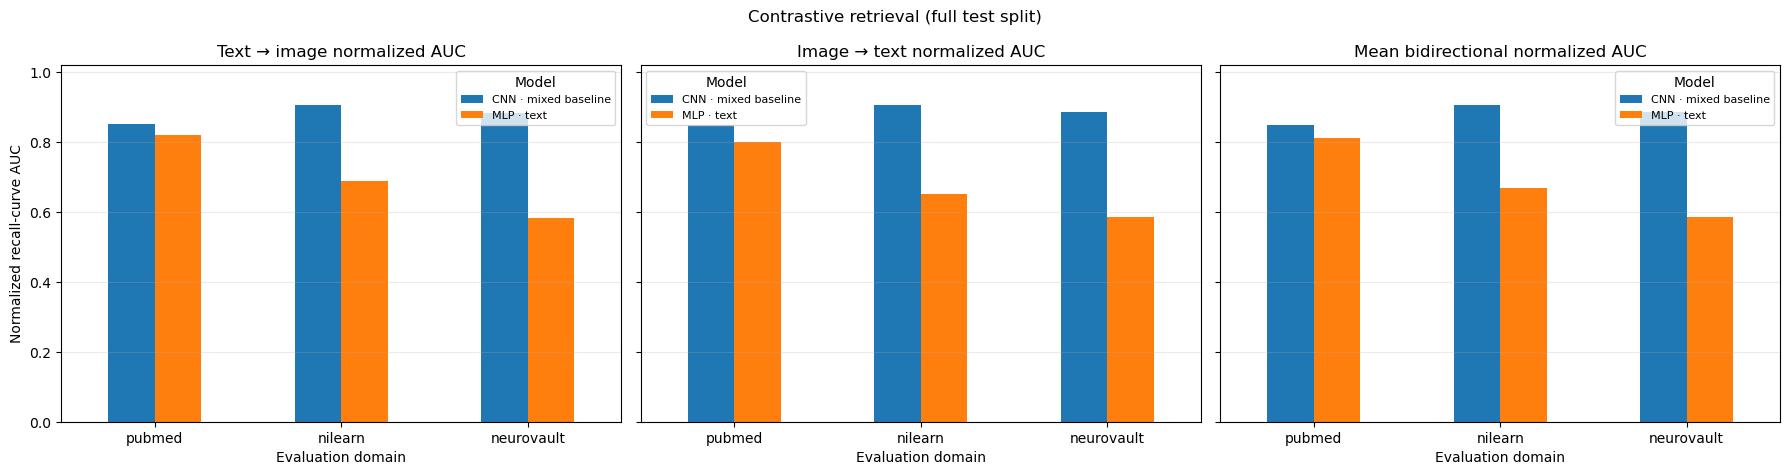

In [3]:
resolved = summary[(summary["status"] == "resolved") & (summary["n"] > 0)].copy()
if resolved.empty:
    raise RuntimeError("No models resolved. Inspect `manifest` for checkpoint errors.")
resolved["model"] = resolved.apply(
    lambda row: f'{row["family"].upper()} · {str(row["variant"]).replace("_", " ")}',
    axis=1,
)

auc_metrics = (
    ("t2i_normalized_k_recall_curve_auc", "Text → image normalized AUC"),
    ("i2t_normalized_k_recall_curve_auc", "Image → text normalized AUC"),
    ("mean_normalized_k_recall_curve_auc", "Mean bidirectional normalized AUC"),
)
fig, axes = plt.subplots(1, len(auc_metrics), figsize=(18, 4.8), sharey=True)
for ax, (metric, title) in zip(axes, auc_metrics):
    table = resolved.pivot(
        index="evaluation_domain", columns="model", values=metric
    ).reindex(DOMAINS)
    table.plot.bar(ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("Evaluation domain")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Model", fontsize=8)
axes[0].set_ylabel("Normalized recall-curve AUC")
fig.suptitle(f"Contrastive retrieval ({EVALUATION_SCOPE})")
fig.tight_layout()
plt.show()


## Normalized recall curves

As in the MLP retrieval plots, the dashed diagonal is random chance. Each model label reports its mean bidirectional normalized AUC.

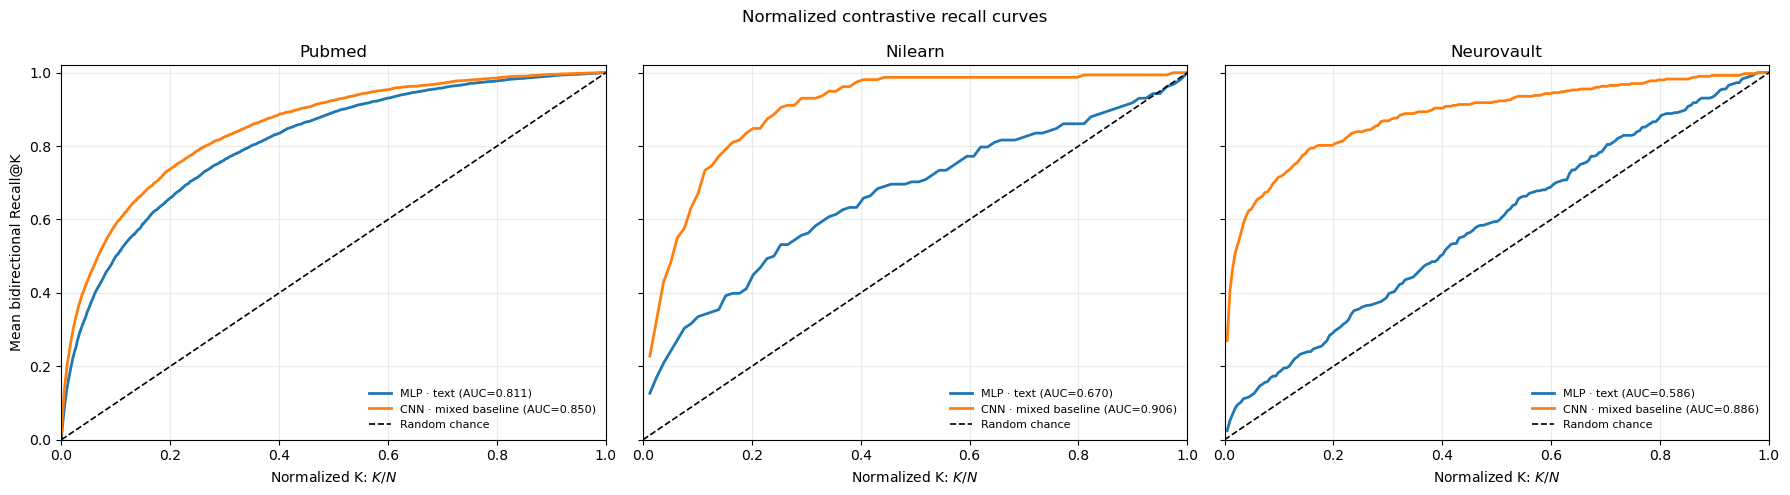

In [4]:
model_labels = resolved.set_index("model_id")["model"].to_dict()
mean_auc = resolved.set_index("model_id")["mean_normalized_k_recall_curve_auc"].to_dict()

fig, axes = plt.subplots(1, len(DOMAINS), figsize=(18, 5), sharex=True, sharey=True)
for ax, domain in zip(axes, DOMAINS):
    domain_curves = recall_curves[recall_curves["evaluation_domain"] == domain]
    for model_id, curve in domain_curves.groupby("model_id", sort=False):
        curve = curve.sort_values("normalized_k")
        ax.plot(
            curve["normalized_k"],
            curve["mean_recall"],
            linewidth=2,
            label=f'{model_labels[model_id]} (AUC={mean_auc[model_id]:.3f})',
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
    ax.set_title(domain.title())
    ax.set_xlabel(r"Normalized K: $K / N$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Mean bidirectional Recall@K")
fig.suptitle("Normalized contrastive recall curves")
fig.tight_layout()
plt.show()
